# Inference Priority Decorator

The `inference_priority` decorator sets request priority for **all LLM calls within its scope**. It works with any LangChain `BaseChatModel` that declares a `priority` Pydantic field — including `ChatNVIDIADynamo`.

> **Priority convention:** lower number = higher priority. `priority=1` is the most urgent.

In agentic workflows, not all LLM calls are equally urgent. A 5-token intent classifier is on the critical path — the user is waiting — while a 500-token background research call has slack. `inference_priority` lets you express this with a single decorator instead of managing separate LLM instances or threading kwargs through every call.

**Key features:**
- Works as both a **decorator** (`@inference_priority(priority=10)`) and a **context manager** (`with inference_priority(priority=10):`)
- **Precedence**: decorator context > instance defaults
- **Nesting**: inner scopes fully replace outer scopes
- **Async-safe**: uses Python `contextvars`, so concurrent async tasks are isolated

## Development Setup

**NOTE** This section is only necessary if you want to run the notebook locally from source. If you just want to use the package, skip to the next section.

If you are working from the `langchain-nvidia` repository, this project uses [Poetry](https://python-poetry.org/) to manage dependencies. Run the following from the `libs/ai-endpoints` directory:

```bash
cd libs/ai-endpoints
pip install poetry                         # if not already installed
poetry config virtualenvs.in-project true --local
poetry install --with test
```

This creates a `.venv` inside `libs/ai-endpoints/`. Then install `ipykernel` directly via the venv's pip and register the Jupyter kernel:

```bash
.venv/bin/pip install ipykernel
.venv/bin/python -m ipykernel install --user --name langchain-nvidia --display-name "langchain-nvidia"
```

After this, reload your editor window and select the **langchain-nvidia** kernel in the notebook kernel picker.

## Install the Package

In [1]:
# Install from local source (inference_priority is not yet in a published release)
%pip install --upgrade --quiet ../../

Note: you may need to restart the kernel to use updated packages.


## Prerequisites

This notebook targets a **local NIM deployment behind NVIDIA Dynamo**. You do not need an `NVIDIA_API_KEY` — the NIM is running on your infrastructure.

See the [Dynamo Quickstart Guide](https://docs.nvidia.com/dynamo/latest/getting-started/quickstart) to get started.

> **Important:** When deploying the model, ensure the Dynamo worker's `--context-length` is at least **2x** the `MAX_TOKENS` value configured below.

In [2]:
NIM_BASE_URL = "http://localhost:8099/v1"
MODEL = "nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-BF16"
MAX_TOKENS = 4096

## Basic Usage — Decorator

With `inference_priority`, you use **one LLM instance** and let the decorator control priority per-function.

In [3]:
from langchain_nvidia_ai_endpoints import ChatNVIDIADynamo, inference_priority

# Single LLM instance — priority is set by context, not by the instance
llm = ChatNVIDIADynamo(
    base_url=NIM_BASE_URL,
    model=MODEL,
    max_completion_tokens=MAX_TOKENS,
)


@inference_priority(priority=1)
def classify_intent(query: str) -> str:
    """Critical path — highest priority (1), short response."""
    return llm.invoke(query, osl=10).content


@inference_priority(priority=10)
def background_research(query: str) -> str:
    """Background work — low priority (10), long response."""
    return llm.invoke(query, osl=500).content


intent = classify_intent("My invoice has the wrong amount")
print(f"Intent: {intent}")

research = background_research("What are common billing dispute policies?")
print(f"Research: {research[:100]}...")

/home/spastoriza/public/langchain-nvidia/libs/ai-endpoints/.venv/lib/python3.13/site-packages/langchain_nvidia_ai_endpoints/chat_models.py:670: UserWarning: Reasoning content was parsed from <think> tags in model output. The tags are currently preserved in the content but will be removed in a future version. The reasoning is available in additional_kwargs['reasoning_content'] and in the reasoning content block in content_blocks. Use reasoning_content instead of parsing tags manually.
  parsed_response = self._custom_postprocess(


Intent: We need to respond as per policy. The user says "My invoice has the wrong amount". Likely needing assistance. As an assistant, we can ask for details, clarify what to do, maybe they need to contact billing, but we can help. There's no policy violation. Provide help. Should ask for invoice details, maybe need to correct. Offer steps: check invoice, contact support, etc. Provide generic advice.
</think>
I’m sorry you’re seeing an incorrect amount on your invoice. I can help you work through the next steps to get it fixed. Could you let me know a few details so I can guide you more precisely?

1. **Which service or product does the invoice relate to?**  
   (e.g., subscription, one‑time purchase, support plan, etc.)

2. **What is the amount that appears on the invoice versus the amount you expected?**  
   (If you have the correct figure, please share it.)

3. **Have you already tried contacting billing support or opened a ticket?**  
   If so, any reference number or response you

## Basic Usage — Context Manager

The same priority control works as a `with` block. This is handy when you want to set priority for a group of calls without defining a separate function.

In [4]:
from langchain_nvidia_ai_endpoints import inference_priority

# High-priority block — user is waiting
with inference_priority(priority=1):
    intent = llm.invoke("My invoice has the wrong amount", osl=10).content
    print(f"Intent: {intent}")

# Low-priority block — background work
with inference_priority(priority=10):
    research = llm.invoke(
        "What are common billing dispute policies?", osl=500
    ).content
    print(f"Research: {research[:100]}...")

Intent: The user says "My invoice has the wrong amount". We need to respond, presumably as a service agent. We should ask for details, offer help, perhaps contact info. No disallowed content. We can respond helpfully. Use polite tone.
</think>
I’m sorry to hear that you’re seeing an incorrect amount on your invoice. I’d be happy to help get this resolved for you.

**To investigate and correct the invoice, could you please provide the following details?**

1. **Invoice number** (the reference at the top or bottom of the document).  
2. **Date of the invoice**.  
3. **Your account or client ID** (if applicable).  
4. **A brief description of the discrepancy** – e.g., “the total should be $ 1,250 but it shows $ 1,500.”  
5. **Any supporting documentation** (e.g., a copy of the invoice, a screenshot, or a statement showing the correct amount).  
6. **Preferred contact information** (email address or phone number) so we can follow up with you quickly.

Once I have this information, I can:



## More Examples

Here are more examples showing high-priority and low-priority functions side by side.

In [5]:
@inference_priority(priority=1)
def classify_sentiment(text: str) -> str:
    """High-priority classification — short response."""
    return llm.invoke(
        f"Classify as positive or negative: '{text}'",
        osl=5,
    ).content


@inference_priority(priority=10)
def summarize_topic(topic: str) -> str:
    """Low-priority background work — long response."""
    return llm.invoke(
        f"Summarize the history of {topic}.",
        osl=500,
    ).content


print(f"Classification: {classify_sentiment('I love this product!')}")
print(f"Summary: {summarize_topic('customer loyalty programs')[:100]}...")

Classification: The user asks to classify as positive or negative a statement: 'I love this product!'. It's clearly positive. So answer: positive.
</think>
**Positive**
Summary: Okay, the user asked for a summary of the history of customer loyalty programs. Let me start by reca...


## Precedence

> **Reminder:** lower number = higher priority. `priority=1` is the most urgent.

The priority hierarchy is:

| Level | Example | Wins? |
|-------|---------|-------|
| Decorator / context manager | `@inference_priority(priority=1)` | When set |
| Instance default | `ChatNVIDIADynamo(priority=10)` | When no decorator |

This means you can set a low-priority default on the instance and override it per-function with the decorator.

In [6]:
llm_with_default = ChatNVIDIADynamo(
    base_url=NIM_BASE_URL,
    model=MODEL,
    max_completion_tokens=MAX_TOKENS,
    priority=10,  # instance default: low priority
)


@inference_priority(priority=1)
def urgent_classification(query: str) -> str:
    """Decorator overrides the instance default of priority=10."""
    return llm_with_default.invoke(query, osl=10).content


# Without the decorator, the instance default (priority=10) is used
result = llm_with_default.invoke("Background task", osl=500)
print(f"Default priority result: {result.content[:80]}...")

# With the decorator, priority=1 overrides the instance default
print(f"Decorator priority result: {urgent_classification('Classify: urgent or not')}")

Default priority result: The user says "Background task". That's ambiguous. Likely they want to start a b...
Decorator priority result: We need to respond to user's request: "Classify: urgent or not". But no context is given. Possibly they want us to classify something as urgent or not. But they haven't provided content. Maybe they want a generic answer? Could ask for clarification. But likely they want us to ask for clarification: we need to know what to classify. So we can respond asking for more information: "please provide the text or description you want classified as urgent or not." 

Thus the appropriate answer: ask for more details.
</think>
Sure—just let me know the specific text, message, or situation you’d like classified, and I’ll tell you whether it should be treated as urgent or not.


## Parallel Fan-Out with Tiered Priority

This example demonstrates the core value of `inference_priority`: **within a single `asyncio.gather()`, different coroutines can carry different priorities**, and the GPU scheduler serves higher-priority requests first.

> **Priority convention:** lower number = higher priority. `priority=1` is the most urgent.

A customer support agent fans out **72 LLM calls** simultaneously across **5 priority tiers**. Each tier has an output-length cap (`max_tokens`) matching its role — critical tasks are short classifications, background tasks are comprehensive reports — with `osl` set to match:

| Priority | Tier | Tasks | max_tokens | osl | Role |
|----------|------|-------|------------|-----|------|
| 1 | CRITICAL | 2 | 128 | 128 | Intent classification, urgency detection |
| 3 | HIGH | 5 | 512 | 512 | Sentiment, escalation, category, routing, tone |
| 5 | MEDIUM | 10 | 1024 | 1024 | Policy, account, history, product, terms, SLA, knowledge base, FAQ, templates, precedent |
| 7 | LOW | 20 | 2048 | 2048 | Shipping, warranty, financial, QC, compliance, logistics, and more |
| 10 | BACKGROUND | 35 | 4096 | 4096 | Benchmarks, competitor analysis, root cause, compensation, forecasting, and more |

```
Customer Query
      │
      └─── asyncio.gather() ──────────────────────────────────────
            │
            ├─ CRITICAL   (priority=1)     2 tasks   max_tokens=128
            ├─ HIGH       (priority=3)     5 tasks   max_tokens=512
            ├─ MEDIUM     (priority=5)    10 tasks   max_tokens=1024
            ├─ LOW        (priority=7)    20 tasks   max_tokens=2048
            └─ BACKGROUND (priority=10)   35 tasks   max_tokens=4096
                                         ──────────
                                         72 tasks total
```

Both **priority scheduling** and **output-length matching** contribute to the staircase pattern — exactly as in a real production system, where critical-path tasks are naturally short and background analytics are longer. The `@inference_priority` decorator ensures the scheduler serves urgent requests first.

> **Note:** Results depend on GPU capacity, model size, and concurrent load. The staircase becomes more pronounced under heavier contention.

In [7]:
import asyncio
import time
from dataclasses import dataclass

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

from langchain_nvidia_ai_endpoints import ChatNVIDIADynamo, inference_priority

# ── Task definitions by priority tier ──────────────────────────────────────────
# Each tier has its own max_tokens: critical tasks generate short output (quick
# classifications), while background tasks produce longer analytical reports.
# osl matches max_tokens so the Dynamo scheduler gets accurate expectations.
# Bottom-heavy distribution (72 total) to saturate the GPU and force queueing.

TIERS = [
    {
        "priority": 1, "label": "CRITICAL", "osl": 128, "max_tokens": 128,
        "tasks": [
            ("intent_classify", "Classify the customer intent in 3 words or fewer."),
            ("urgency_detect", "Rate urgency as: low / medium / high. One word only."),
        ],
    },
    {
        "priority": 3, "label": "HIGH", "osl": 512, "max_tokens": 512,
        "tasks": [
            ("sentiment", "Analyze customer sentiment in detail."),
            ("escalation", "Determine if this needs manager escalation. Justify in detail."),
            ("category", "Categorize into a support category with full reasoning."),
            ("routing", "Determine the correct department and explain why in detail."),
            ("tone", "Analyze the customer's communication tone and frustration level."),
        ],
    },
    {
        "priority": 5, "label": "MEDIUM", "osl": 1024, "max_tokens": 1024,
        "tasks": [
            ("policy", "Identify all relevant company policies for this query."),
            ("account", "Review the customer's account history in detail."),
            ("history", "Check for similar past support tickets and outcomes."),
            ("product", "Identify potential product defects mentioned and their severity."),
            ("terms", "Review the terms and conditions relevant to this case."),
            ("sla", "Check SLA requirements for this customer tier."),
            ("knowledge_base", "Search the knowledge base for relevant articles."),
            ("faq_match", "Find FAQ entries that match this customer issue."),
            ("template_match", "Identify response templates for this issue type."),
            ("precedent", "Find precedent cases and how they were resolved."),
        ],
    },
    {
        "priority": 7, "label": "LOW", "osl": 2048, "max_tokens": 2048,
        "tasks": [
            ("shipping", "Research shipping carrier reliability data with statistics."),
            ("warranty", "Provide a comprehensive review of warranty and return policies."),
            ("financial", "Analyze the full financial impact of this complaint."),
            ("quality", "Review recent quality control reports and trend analysis."),
            ("compliance", "Conduct a full regulatory compliance review for this case."),
            ("inventory", "Check inventory status for replacement items."),
            ("supplier", "Research supplier quality metrics for this product."),
            ("logistics", "Analyze logistics chain for delivery issues."),
            ("packaging", "Review packaging standards for fragile items."),
            ("insurance", "Check shipping insurance coverage details."),
            ("seasonal", "Analyze seasonal patterns in damage reports."),
            ("warehouse", "Review warehouse handling procedures."),
            ("carrier_compare", "Compare carrier damage rates across providers."),
            ("regional", "Analyze regional delivery performance data."),
            ("vendor_score", "Calculate vendor reliability scores for this product line."),
            ("claims_review", "Review the full claims history for this product category."),
            ("damage_assessment", "Assess the severity of reported damages."),
            ("return_process", "Document and evaluate the return process end-to-end."),
            ("refund_timeline", "Estimate refund processing time and identify bottlenecks."),
            ("delivery_tracking", "Analyze delivery tracking data for this shipment."),
        ],
    },
    {
        "priority": 10, "label": "BACKGROUND", "osl": 4096, "max_tokens": 4096,
        "tasks": [
            ("benchmarks", "Write a detailed industry benchmark report for resolution times."),
            ("competitor", "Write a comprehensive competitor refund policy analysis."),
            ("root_cause", "Conduct a thorough root cause analysis of recurring damage."),
            ("compensation", "Draft multiple compensation options with cost-benefit analysis."),
            ("process", "Write a detailed process improvement proposal to prevent recurrence."),
            ("cross_sell", "Identify cross-sell or retention opportunities."),
            ("churn_risk", "Assess churn risk for this customer."),
            ("nps_impact", "Estimate impact on net promoter score."),
            ("training", "Identify agent training opportunities from this case."),
            ("automation", "Identify automation opportunities for this issue type."),
            ("forecast", "Forecast volume of similar complaints next quarter."),
            ("social_media", "Monitor social media for related complaints."),
            ("documentation", "Draft internal documentation for this case pattern."),
            ("ab_test", "Suggest A/B tests for resolution strategies."),
            ("knowledge_update", "Draft knowledge base article from this resolution."),
            ("market_analysis", "Conduct a market analysis for this product segment."),
            ("lifetime_value", "Calculate customer lifetime value for this segment."),
            ("sentiment_trends", "Analyze sentiment trends across quarters."),
            ("response_quality", "Assess response quality metrics for this category."),
            ("escalation_patterns", "Identify escalation patterns in similar cases."),
            ("resolution_time", "Analyze average resolution times by issue type."),
            ("cost_analysis", "Calculate cost of unresolved complaints."),
            ("feedback_loop", "Design a customer feedback loop for this product."),
            ("sla_compliance", "Review SLA compliance statistics for this quarter."),
            ("capacity_planning", "Forecast support capacity needs for next quarter."),
            ("quality_scoring", "Develop a quality scoring framework for support agents."),
            ("risk_modeling", "Build a risk model for customer churn."),
            ("process_audit", "Conduct a full process audit for order fulfillment."),
            ("vendor_assessment", "Assess vendor performance across all metrics."),
            ("training_curriculum", "Draft agent training curriculum for damage cases."),
            ("policy_gaps", "Identify gaps in current refund and return policies."),
            ("dashboard_design", "Design a support analytics dashboard."),
            ("workflow_optimization", "Optimize support workflow for damage complaints."),
            ("customer_journey", "Map the full customer journey for this case."),
            ("impact_report", "Draft a comprehensive impact report for leadership."),
        ],
    },
]

# ── Per-tier LLMs (each tier has its own max_completion_tokens) ────────────────
# Critical tasks get a small token budget (short classifications), while
# background tasks get the full budget (comprehensive reports).

llm_by_priority = {}
for tier in TIERS:
    llm_by_priority[tier["priority"]] = ChatNVIDIADynamo(
        base_url=NIM_BASE_URL,
        model=MODEL,
        max_completion_tokens=tier["max_tokens"],
    )

# ── Build chains from tier definitions ─────────────────────────────────────────

chains = {}  # name -> (chain, priority, osl)
for tier in TIERS:
    tier_llm = llm_by_priority[tier["priority"]]
    for name, system_prompt in tier["tasks"]:
        chain = (
            ChatPromptTemplate.from_messages([
                ("system", f"{system_prompt} Be thorough."),
                ("user", "{query}"),
            ])
            | tier_llm.bind(osl=tier["osl"])
            | StrOutputParser()
        )
        chains[name] = (chain, tier["priority"], tier["osl"])

print(f"Built {len(chains)} chains across {len(TIERS)} priority tiers")
for tier in TIERS:
    print(f"  {tier['label']:12s} (priority={tier['priority']:2d}): "
          f"{len(tier['tasks'])} tasks, osl={tier['osl']}, "
          f"max_tokens={tier['max_tokens']}")


# ── Timing helper ──────────────────────────────────────────────────────────────

@dataclass
class StageResult:
    name: str
    result: str
    start: float   # seconds relative to run t0
    end: float     # seconds relative to run t0
    priority: int


async def timed_call(chain, name: str, query: str, t0: float) -> StageResult:
    """Run a chain and record wall-clock start/end relative to t0."""
    start = time.perf_counter()
    result = await chain.ainvoke({"query": query})
    end = time.perf_counter()
    priority = chains[name][1]
    return StageResult(
        name=name, result=result,
        start=start - t0, end=end - t0, priority=priority,
    )


# ── Decorated wrappers: one per priority tier ──────────────────────────────────

@inference_priority(priority=1)
async def critical_call(chain, name: str, query: str, t0: float) -> StageResult:
    return await timed_call(chain, name, query, t0)

@inference_priority(priority=3)
async def high_call(chain, name: str, query: str, t0: float) -> StageResult:
    return await timed_call(chain, name, query, t0)

@inference_priority(priority=5)
async def medium_call(chain, name: str, query: str, t0: float) -> StageResult:
    return await timed_call(chain, name, query, t0)

@inference_priority(priority=7)
async def low_call(chain, name: str, query: str, t0: float) -> StageResult:
    return await timed_call(chain, name, query, t0)

@inference_priority(priority=10)
async def background_call(chain, name: str, query: str, t0: float) -> StageResult:
    return await timed_call(chain, name, query, t0)

# Map priority -> wrapper function
PRIORITY_WRAPPERS = {
    1: critical_call,
    3: high_call,
    5: medium_call,
    7: low_call,
    10: background_call,
}

Built 72 chains across 5 priority tiers
  CRITICAL     (priority= 1): 2 tasks, osl=128, max_tokens=128
  HIGH         (priority= 3): 5 tasks, osl=512, max_tokens=512
  MEDIUM       (priority= 5): 10 tasks, osl=1024, max_tokens=1024
  LOW          (priority= 7): 20 tasks, osl=2048, max_tokens=2048
  BACKGROUND   (priority=10): 35 tasks, osl=4096, max_tokens=4096


In [8]:
customer_query = (
    "I've been a loyal customer for 5 years, but my last three orders "
    "have all arrived damaged. I was charged $149.99 and still haven't "
    "received a refund."
)


async def run_with_tiered_priority(query: str) -> list[StageResult]:
    """Fan out all tasks with per-tier @inference_priority decorators."""
    t0 = time.perf_counter()
    tasks = []
    for name, (chain, priority, _osl) in chains.items():
        wrapper = PRIORITY_WRAPPERS[priority]
        tasks.append(wrapper(chain, name, query, t0))
    return list(await asyncio.gather(*tasks))


# ── Warmup ─────────────────────────────────────────────────────────────────────
warmup_llm = llm_by_priority[1]  # use any tier's LLM
print("Warming up GPU with 20 concurrent calls...")
warmup_tasks = [warmup_llm.ainvoke("Warm up the GPU.", osl=500) for _ in range(20)]
await asyncio.gather(*warmup_tasks)
print("Warmup done.\n")


# ── Execute ────────────────────────────────────────────────────────────────────
TIER_LABELS = {t["priority"]: t["label"] for t in TIERS}

print(f"Running {len(chains)} parallel calls with 5 priority tiers...")
stages = await run_with_tiered_priority(customer_query)
print(f"  Total wall clock: {max(s.end for s in stages):.2f}s\n")

print("Per-tier completion times:")
print(f"  {'Tier':12s}  {'Priority':>8s}  {'Tasks':>5s}  {'Done at':>8s}")
print(f"  {'─' * 12}  {'─' * 8}  {'─' * 5}  {'─' * 8}")
for pri in sorted(TIER_LABELS):
    tier_stages = [s for s in stages if s.priority == pri]
    if tier_stages:
        done_at = max(s.end for s in tier_stages)
        print(f"  {TIER_LABELS[pri]:12s}  {pri:>8d}  {len(tier_stages):>5d}  {done_at:>7.2f}s")

Warming up GPU with 20 concurrent calls...


/home/spastoriza/public/langchain-nvidia/libs/ai-endpoints/.venv/lib/python3.13/site-packages/langchain_nvidia_ai_endpoints/chat_models.py:670: UserWarning: Reasoning content was parsed from <think> tags in model output. The tags are currently preserved in the content but will be removed in a future version. The reasoning is available in additional_kwargs['reasoning_content'] and in the reasoning content block in content_blocks. Use reasoning_content instead of parsing tags manually.
  parsed_response = self._custom_postprocess(


Warmup done.

Running 72 parallel calls with 5 priority tiers...
  Total wall clock: 65.70s

Per-tier completion times:
  Tier          Priority  Tasks   Done at
  ────────────  ────────  ─────  ────────
  CRITICAL             1      2     2.99s
  HIGH                 3      5    13.19s
  MEDIUM               5     10    24.83s
  LOW                  7     20    43.35s
  BACKGROUND          10     35    65.70s


### Execution Timeline

The Gantt chart below shows all 72 tasks grouped by priority tier and color-coded. The dashed vertical lines mark when each tier's last task completes.

Look for the **staircase pattern** — priority=1 (red) tasks complete first, then priority=3 (orange), and so on. The further apart the dashed lines, the more the priority scheduler is differentiating between tiers.

Note: you may need to restart the kernel to use updated packages.


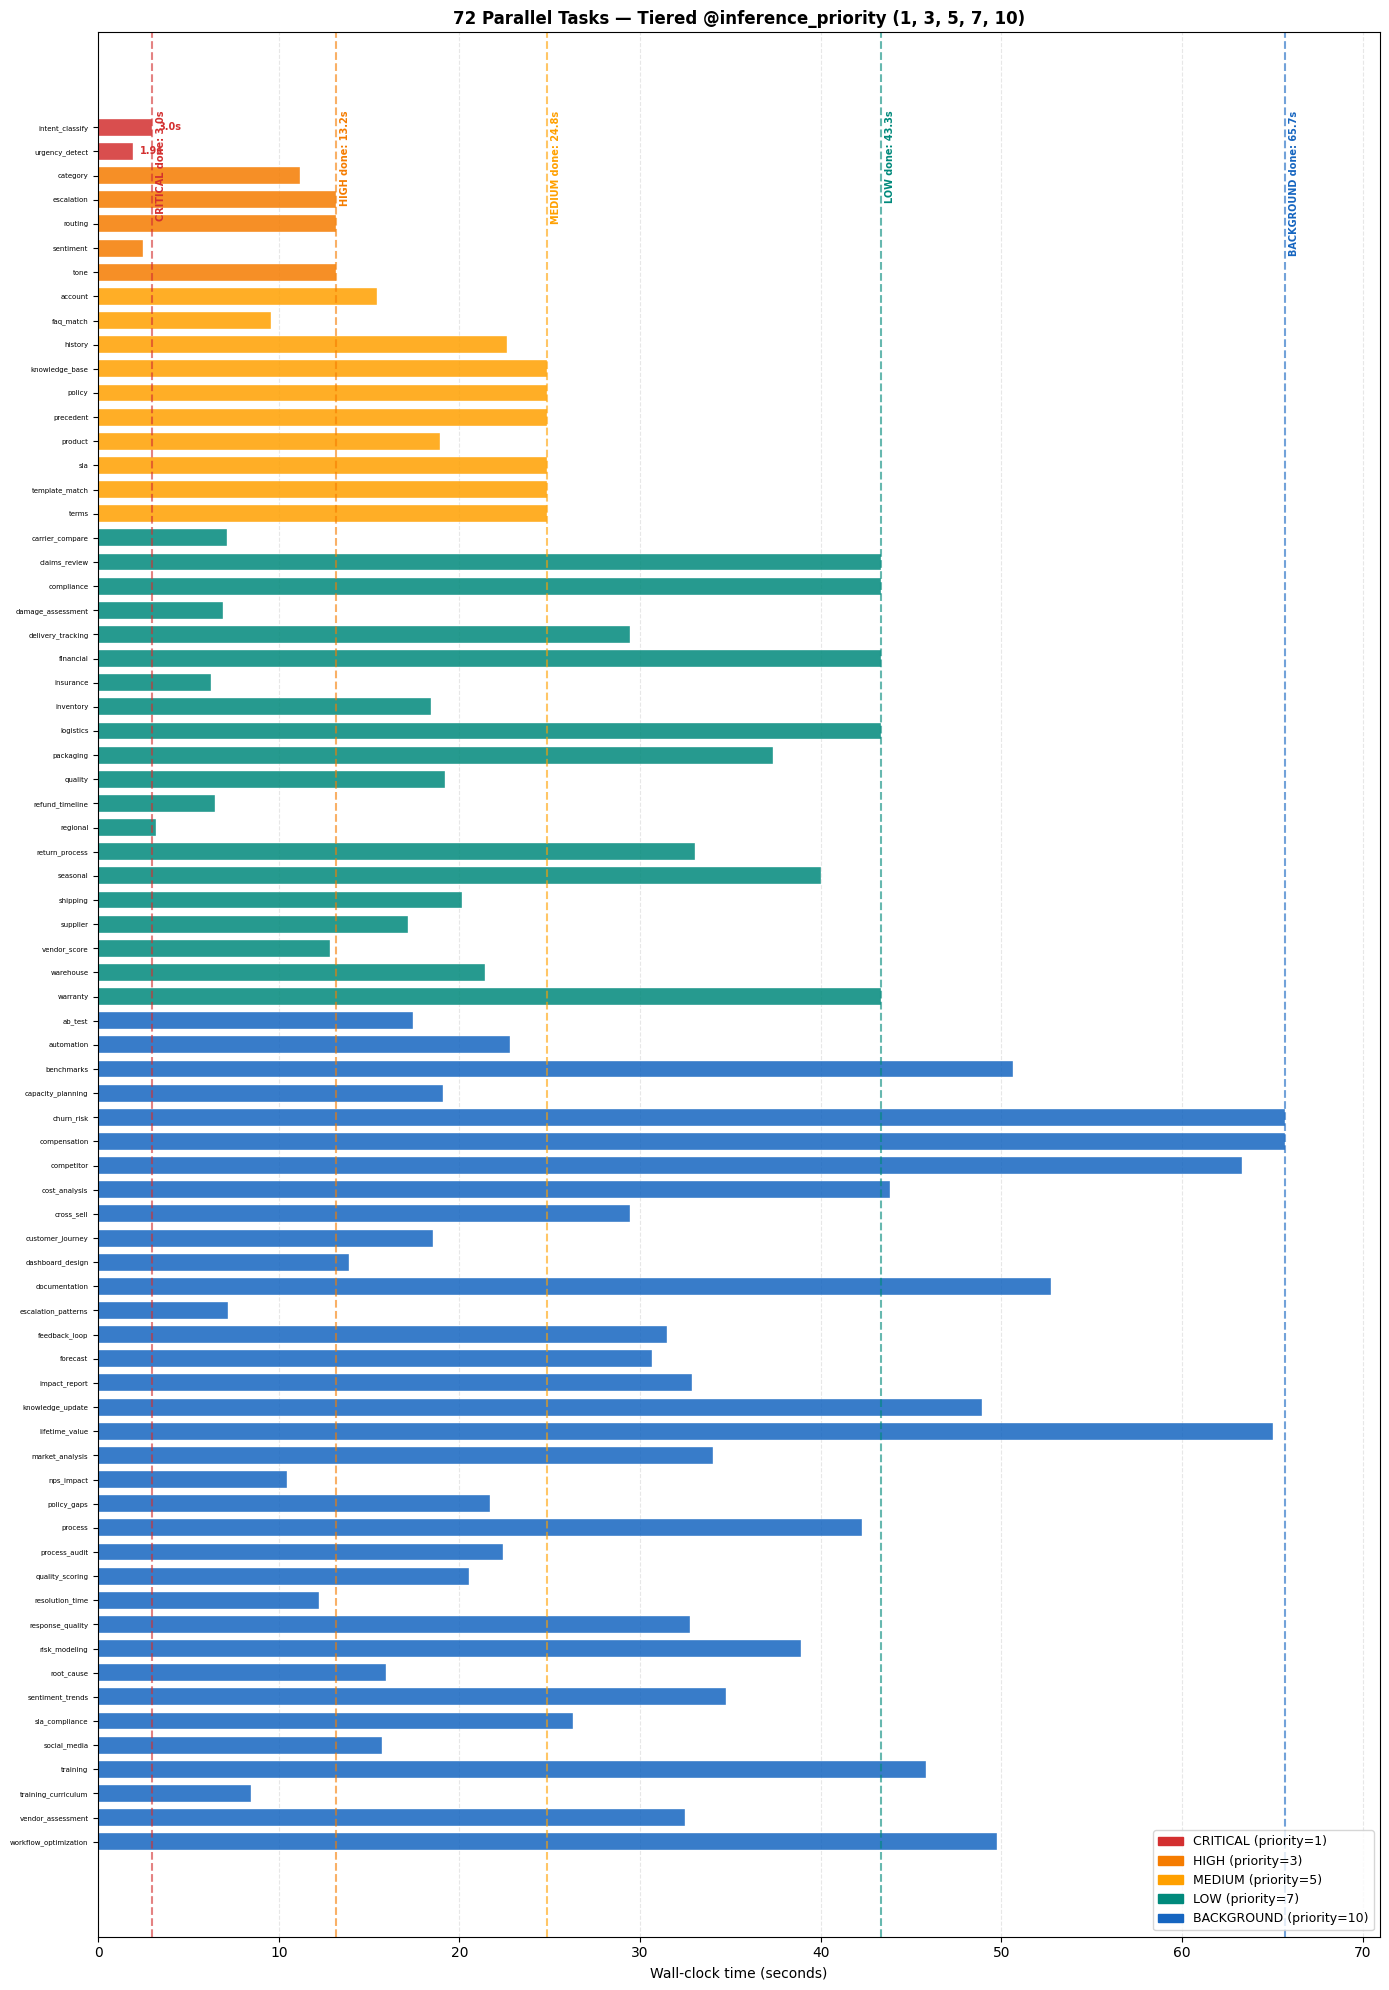

In [9]:
%pip install --quiet matplotlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Color scheme: warm → cool as priority increases (lower = more urgent) ──────
COLORS = {
    1:  "#d32f2f",   # red    — CRITICAL
    3:  "#f57c00",   # orange — HIGH
    5:  "#ffa000",   # amber  — MEDIUM
    7:  "#00897b",   # teal   — LOW
    10: "#1565c0",   # blue   — BACKGROUND
}
TIER_LABELS = {t["priority"]: t["label"] for t in TIERS}


def make_gantt(ax, stages: list[StageResult], title: str) -> None:
    """Draw a horizontal bar chart grouped by priority tier."""
    # Group by tier priority, then sort within each group by name
    ordered = []
    for pri in sorted(COLORS):
        tier_stages = sorted(
            [s for s in stages if chains[s.name][1] == pri],
            key=lambda s: s.name,
        )
        ordered.extend(tier_stages)

    x_max = max(s.end for s in stages) * 1.08
    n = len(ordered)
    y_labels = []

    for i, s in enumerate(reversed(ordered)):
        pri = chains[s.name][1]
        color = COLORS[pri]
        duration = s.end - s.start
        ax.barh(i, duration, left=s.start, height=0.7,
                color=color, edgecolor="white", linewidth=0.3, alpha=0.85)
        if pri == 1:
            ax.text(s.end + x_max * 0.005, i, f"{duration:.1f}s",
                    ha="left", va="center",
                    fontsize=7, fontweight="bold", color=color)
        y_labels.append(s.name)

    ax.set_yticks(range(n))
    ax.set_yticklabels(y_labels, fontsize=5)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Wall-clock time (seconds)", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    # Dashed vertical lines at each tier's completion time
    for pri in sorted(COLORS):
        tier_stages = [s for s in stages if chains[s.name][1] == pri]
        if tier_stages:
            tier_done = max(s.end for s in tier_stages)
            ax.axvline(tier_done, color=COLORS[pri], linestyle="--",
                       linewidth=1.5, alpha=0.6)
            ax.text(tier_done + x_max * 0.003, n - 0.3,
                    f"{TIER_LABELS[pri]} done: {tier_done:.1f}s",
                    fontsize=7, color=COLORS[pri], va="top",
                    fontweight="bold", rotation=90)


fig, ax = plt.subplots(1, 1, figsize=(14, 20))

make_gantt(ax, stages,
           "72 Parallel Tasks — Tiered @inference_priority (1, 3, 5, 7, 10)")

# Legend
legend_handles = [
    mpatches.Patch(color=COLORS[pri], label=f"{TIER_LABELS[pri]} (priority={pri})")
    for pri in sorted(COLORS)
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## Before & After Comparison

### Before: Priority Baked Into Instances

Without `inference_priority`, **every priority tier needs its own `ChatNVIDIADynamo` instance** with a hardcoded priority. With 5 priority levels and different output lengths, that's 5 tightly coupled instances where priority is entangled with infrastructure config:

```python
# Five instances — one per priority tier × output length
llm_p1  = ChatNVIDIADynamo(base_url=URL, model=MODEL, priority=1,  max_completion_tokens=128)
llm_p3  = ChatNVIDIADynamo(base_url=URL, model=MODEL, priority=3,  max_completion_tokens=512)
llm_p5  = ChatNVIDIADynamo(base_url=URL, model=MODEL, priority=5,  max_completion_tokens=1024)
llm_p7  = ChatNVIDIADynamo(base_url=URL, model=MODEL, priority=7,  max_completion_tokens=2048)
llm_p10 = ChatNVIDIADynamo(base_url=URL, model=MODEL, priority=10, max_completion_tokens=4096)

# Must remember which instance to use for each chain — priority is implicit
intent_chain    = prompt | llm_p1.bind(osl=128)  | parser
sentiment_chain = prompt | llm_p3.bind(osl=512)  | parser
policy_chain    = prompt | llm_p5.bind(osl=1024) | parser
shipping_chain  = prompt | llm_p7.bind(osl=2048) | parser
benchmarks_chain = prompt | llm_p10.bind(osl=4096) | parser

# Fan out — priority is hidden inside the instance
results = await asyncio.gather(
    intent_chain.ainvoke({"query": query}),      # llm_p1 → priority=1
    sentiment_chain.ainvoke({"query": query}),   # llm_p3 → priority=3
    policy_chain.ainvoke({"query": query}),      # llm_p5 → priority=5
    shipping_chain.ainvoke({"query": query}),    # llm_p7 → priority=7
    benchmarks_chain.ainvoke({"query": query}),  # llm_p10 → priority=10
)
```

### After: Priority in Business Logic

With `inference_priority`, **LLM instances are configured by output characteristics** (max_tokens) and **priority lives in the business logic** — on the function that calls the LLM:

```python
# LLM instances configured by output length — NOT by priority
llm_short  = ChatNVIDIADynamo(base_url=URL, model=MODEL, max_completion_tokens=128)
llm_medium = ChatNVIDIADynamo(base_url=URL, model=MODEL, max_completion_tokens=1024)
llm_long   = ChatNVIDIADynamo(base_url=URL, model=MODEL, max_completion_tokens=4096)

# Chains use whichever LLM matches their output needs
intent_chain     = prompt | llm_short.bind(osl=128)  | parser
sentiment_chain  = prompt | llm_medium.bind(osl=512) | parser
policy_chain     = prompt | llm_medium.bind(osl=1024) | parser
shipping_chain   = prompt | llm_long.bind(osl=2048) | parser
benchmarks_chain = prompt | llm_long.bind(osl=4096) | parser

# Priority is explicit per-function via the decorator
@inference_priority(priority=1)
async def critical_call(chain, query):
    return await chain.ainvoke({"query": query})

@inference_priority(priority=10)
async def background_call(chain, query):
    return await chain.ainvoke({"query": query})

# Fan out — priority is visible and separate from chain construction
results = await asyncio.gather(
    critical_call(intent_chain, query),        # priority=1
    background_call(benchmarks_chain, query),  # priority=10
)
```

### Summary

<table>
  <thead>
    <tr>
      <th style="text-align:left">Aspect</th>
      <th style="text-align:center">Priority Baked Into Instances</th>
      <th style="text-align:center"><code>@inference_priority</code> Decorator</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>LLM instances carry</td>
      <td style="text-align:center">Priority + output config (tightly coupled)</td>
      <td style="text-align:center; background-color:#f0f7f0"><strong>Output config only (priority is separate)</strong></td>
    </tr>
    <tr>
      <td>Priority lives in</td>
      <td style="text-align:center">Infrastructure (instance config)</td>
      <td style="text-align:center; background-color:#f0f7f0"><strong>Business logic (function decorator)</strong></td>
    </tr>
    <tr>
      <td>Adding a new priority tier</td>
      <td style="text-align:center">Create another instance</td>
      <td style="text-align:center; background-color:#f0f7f0"><strong>Add one decorated wrapper</strong></td>
    </tr>
    <tr>
      <td>Change priority</td>
      <td style="text-align:center">Rewire chains to a different instance</td>
      <td style="text-align:center; background-color:#f0f7f0"><strong>Change decorator argument</strong></td>
    </tr>
    <tr>
      <td>Nesting support</td>
      <td style="text-align:center">&mdash;</td>
      <td style="text-align:center; background-color:#f0f7f0"><strong>Yes</strong> (inner replaces outer)</td>
    </tr>
    <tr>
      <td>Async-safe</td>
      <td style="text-align:center">Yes (separate instances)</td>
      <td style="text-align:center; background-color:#f0f7f0"><strong>Yes</strong> (contextvars)</td>
    </tr>
    <tr>
      <td>Changes to existing clients</td>
      <td style="text-align:center">None</td>
      <td style="text-align:center">None</td>
    </tr>
  </tbody>
</table>

## Related Topics

- [ChatNVIDIADynamo Notebook](nvidia_ai_endpoints_dynamo.ipynb) — Dynamo-specific parameters (`osl`, `iat`, `latency_sensitivity`)
- [NVIDIA Dynamo](https://developer.nvidia.com/dynamo) — open-source inference framework
- [Dynamo Quickstart Guide](https://docs.nvidia.com/dynamo/latest/getting-started/quickstart)
- [ChatNVIDIA Documentation](nvidia_ai_endpoints.ipynb) — standard ChatNVIDIA usage
- [langchain-nvidia-ai-endpoints README](https://github.com/langchain-ai/langchain-nvidia/blob/main/libs/ai-endpoints/README.md)